In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.img_converter import ImgConverter
from converters.line_heuristics.random_search import RandomLineSearch
from rendering.image import render_symbols_img

from tests.experimental.test_loop import lazy_converter_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
MAX_COLS = 20
MAX_LINES = 10
NUM_IMGS = 10
GENS = 20
GENS_STEP = 5
IMG_SET_PATH = "../../../../imgs/BSDS500-ds"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:NUM_IMGS]]


In [2]:
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery

line_converter = RandomLineSearch(symbols=SYMBOLS,
                                  font=FONT,
                                  generations=GENS)

converter = ImgConverter(line_converter, FONT)

line_height = int(FONT_SIZE * 1.333)
col_width = int(line_height / 2)

results = []
for img_path in IMG_PATHS[:6]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = converter.img2symbols(img,
                                    max_cols=MAX_COLS,
                                    max_lines=MAX_LINES,
                                    col_width=col_width,
                                    line_height=line_height,
                                    gens_per_step=1000)
    results.append(res_arr)

print_gallery(results, 3)

----------------------------------------------------------------------
| 7Rlz%WAd%$(E7MFWu`nY | xjYt2c`\uia )0$@e\ii | \`,),?,0u|<AB>W)%iE= |
| 'l- Wg}rC-gxUk-*%O\Y | MO.+)S^JKGn<$'S3/O2R | S!XtJC@?R1)mysr.+r2D |
| K=!x$$/d<9Lq8ncmIO;" | tEB0xT\kdi{`C^TP'|o/ | ~H*B'#.yN28pXs6fDD*I |
| ^iS)/YZ_(Fa#tQx=E]v; | 1Jg7!FmH>`Y^UM5:UM|+ | #S>g"4]Y&0%{%n[p 7B= |
| +f>2Zs^w]Lt%fif`)'l^ | a'nDC=g6oU.VqVBB+.63 | OW$3A_@f~R F99p@0~8f |
| %H{5Q$N.'S$Hl)@Svi~c | ~_$cm<vrpZj,N&H:o.Vh | X84@cD[ ic?]_!eP{3D{ |
| v]{^vs(g&10me",OA>XZ | Dh(2ZFH_K6aIKG"q0haH | Y"`{i_Q)'lk?u&v)Xazz |
----------------------------------------------------------------------
----------------------------------------------------------------
| !^'/1_vt.E/0.E | @uA#kW'Gl1LQM#dvR@!o | 89wwH'~oSAm&U(Yq2@su |
| G yvw<-_penP;| | y2q(m/W h-G/=M4|J%e4 | Z!Ym<6ZL.C>{@{[SdToN |
| M?6M><L4[lAJSm | =Z974QW$wvlTcOpE4k=Q | Ah$1'w L&@33LkVt_;@# |
| aF=LfyRI&~*<m4 | %eb}cN~G!rxCUk=O4p'' | N'Dgd-{@C`:|2u34?*.| |
| _frKhT|^=1iv-y | f481,,pVlF!o6NX*^

Min: -0.0031 | Max: 0.0948 | Mean: 0.0492 | Std: 0.0250
Min: 0.0371 | Max: 0.1368 | Mean: 0.0739 | Std: 0.0309
Min: 0.0371 | Max: 0.1386 | Mean: 0.0758 | Std: 0.0306
Min: 0.0422 | Max: 0.1411 | Mean: 0.0786 | Std: 0.0299


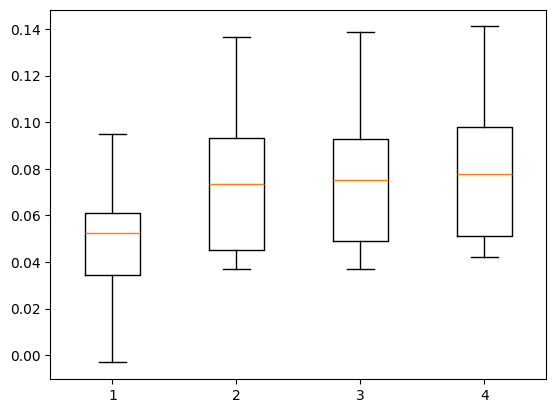

In [3]:
similarity_scores = lazy_converter_loop(IMG_PATHS,
                                        converter,
                                        FONT,
                                        max_cols=MAX_COLS,
                                        max_lines=MAX_LINES,
                                        col_width=col_width,
                                        line_height=line_height,
                                        gens=GENS,
                                        gens_per_step=GENS_STEP)

plt.boxplot(similarity_scores)
plt.show()
        

Min: 0.0070 | Max: 0.0570 | Mean: 0.0350 | Std: 0.0164
Min: 0.0089 | Max: 0.0801 | Mean: 0.0575 | Std: 0.0203
Min: 0.0354 | Max: 0.0774 | Mean: 0.0634 | Std: 0.0124
Min: 0.0427 | Max: 0.0881 | Mean: 0.0651 | Std: 0.0128


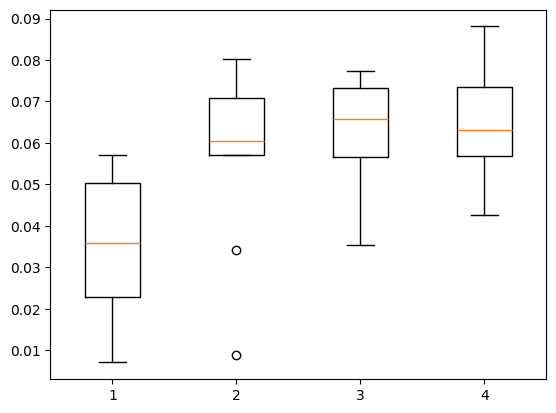

In [4]:
IMG_BIN_SET_PATH = "../../../../imgs/BSDS500-ds-bin"
IMG_BIN_PATHS = [os.path.join(IMG_BIN_SET_PATH, img_name)
                 for img_name in os.listdir(IMG_BIN_SET_PATH)[:NUM_IMGS]]

similarity_scores = lazy_converter_loop(IMG_BIN_PATHS,
                                        converter,
                                        FONT,
                                        max_cols=MAX_COLS,
                                        max_lines=MAX_LINES,
                                        col_width=col_width,
                                        line_height=line_height,
                                        gens=GENS,
                                        gens_per_step=GENS_STEP)

plt.boxplot(similarity_scores)
plt.show()
        

Min: 0.0163 | Max: 0.0865 | Mean: 0.0526 | Std: 0.0216
Min: 0.0073 | Max: 0.1177 | Mean: 0.0677 | Std: 0.0315
Min: 0.0189 | Max: 0.1222 | Mean: 0.0736 | Std: 0.0284
Min: 0.0056 | Max: 0.1248 | Mean: 0.0802 | Std: 0.0294


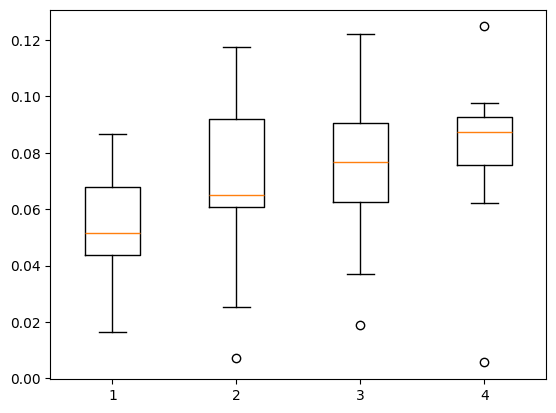

In [5]:
IMG_EDGE_SET_PATH = "../../../../imgs/BSDS500-ds-edge-bin"
IMG_EDGE_PATHS = [os.path.join(IMG_EDGE_SET_PATH, img_name)
                  for img_name in os.listdir(IMG_EDGE_SET_PATH)[:NUM_IMGS]]

similarity_scores = lazy_converter_loop(IMG_EDGE_PATHS,
                                        converter,
                                        FONT,
                                        max_cols=MAX_COLS,
                                        max_lines=MAX_LINES,
                                        col_width=col_width,
                                        line_height=line_height,
                                        gens=GENS,
                                        gens_per_step=GENS_STEP)

plt.boxplot(similarity_scores)
plt.show()
        